# Crude to Vacuum on One Characterization

The atmospheric residue a crude unit makes is the vacuum column's feed. If the
two units describe the oil with different pseudo-components, the connection
between them is a re-cut: the residue is re-characterized, light ends and
contaminants are redistributed, and the derivative of a vacuum product with
respect to anything upstream passes through an interpolation nobody wrote down.

Here one `Assay` is characterized **once**, and that characterization is used
by all three consumers:

1. the crude distillation unit (`CrudeDistillationUnit`), whose thermo is
   `ColumnThermo.from_characterization(char)`;
2. the vacuum column (`VacuumColumn`), whose property table is
   `char.pseudo_components()`, the same grid with the same Tb, SG and MW;
3. the blend pool (`BlendCharacterization.from_characterization(char)`), which
   gets per-cut sulfur, nitrogen and CCR from the same place.

The assay carries a `HeavyEnd`. It extends the TBP curve past its last point on
a probability scale to the vacuum range, and closes the crude with a residue
lump. It also carries bulk contaminants, which are distributed over the cuts so
that they recombine exactly to the bulk values.

In [1]:
import time
import warnings

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from difflow.flowsheet import Flowsheet, Unit
import difflow_refinery as dr
from difflow_refinery import column as cc
from difflow_refinery.thermo import WATER_MW, ColumnThermo
from difflow_refinery.vacuum import VacuumColumn, VacuumColumnParams
from difflow_refinery.vacuum.thermo import MW_WATER

C = 273.15

## 1. One assay, one characterization

A medium-sour crude: an 11-point TBP curve to 680 C, light ends, and bulk
sulfur, nitrogen, Conradson carbon, Ni+V and asphaltenes. With a `heavy_end`,
`characterize` defaults to the 1984 form of Twu's correlation, which stays
defined into the vacuum range.

method twu_1984: 37 components (3 light ends, 34 pseudo-components, residue lump True)
bulk SG 0.8600, bulk S 1.800 wt%


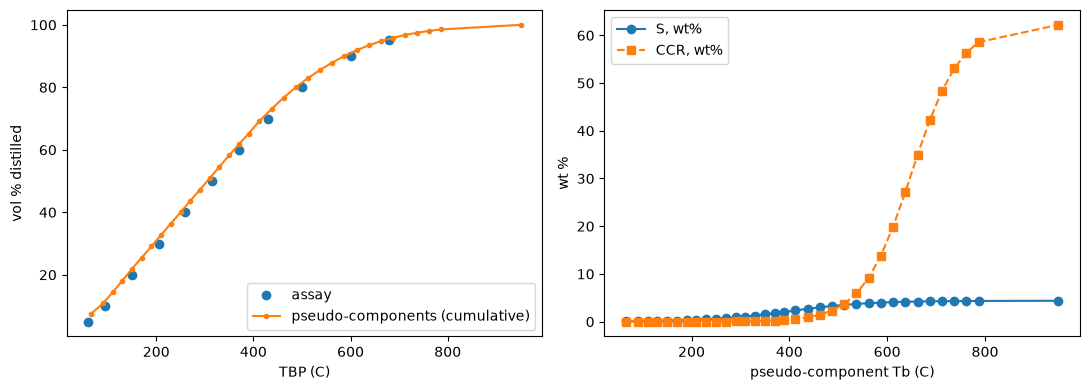

In [2]:
PCT = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95]
T_C = [60, 95, 150, 205, 260, 315, 370, 430, 500, 600, 680]
LIGHT = {"propane": 0.5, "n_butane": 1.0, "n_pentane": 1.5}
ASSAY = dr.Assay(PCT, [t + C for t in T_C], sg=0.86, light_ends=LIGHT,
                 heavy_end=dr.HeavyEnd(),
                 sulfur_wt=1.8, nitrogen_wppm=1500.0, ccr_wt=6.0,
                 nickel_vanadium_wppm=60.0, asphaltenes_wt=3.0)
char = dr.characterize(ASSAY)
k = len(char.light_names)
print(f"method {char.method}: {len(char.names)} components "
      f"({k} light ends, {len(char.pseudo_names)} pseudo-components, residue lump {char.residue_lump})")
print(f"bulk SG {float(char.bulk_sg):.4f}, bulk S {100*float(jnp.sum(char.mass_fraction*char.sulfur)):.3f} wt%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
Tb = np.asarray(char.Tb) - C
ax[0].plot(np.asarray(T_C), PCT, "o", label="assay")
ax[0].plot(Tb, 100 * np.cumsum(np.asarray(char.volume_fraction)[k:]) + 100 * float(jnp.sum(char.volume_fraction[:k])),
           ".-", label="pseudo-components (cumulative)")
ax[0].set_xlabel("TBP (C)"); ax[0].set_ylabel("vol % distilled"); ax[0].legend()
ax[1].plot(Tb, 100 * np.asarray(char.sulfur)[k:], "o-", label="S, wt%")
ax[1].plot(Tb, 100 * np.asarray(char.ccr)[k:], "s--", label="CCR, wt%")
ax[1].set_xlabel("pseudo-component Tb (C)"); ax[1].set_ylabel("wt %"); ax[1].legend()
plt.tight_layout()

## 2. The two units

The crude unit is a 30-stage atmospheric column with three side strippers and
two pumparounds. Its specs are the product rates as fractions of the feed
volume, the pumparound duties and temperature drops, and a 5% overflash. The
vacuum column is built on `char.pseudo_components()`, so the crude unit's
residue goes into it as it is, with no conversion. Everything else is the
`VacuumColumnParams` default, including a 400 C coil outlet.

In [3]:
BPD = 95_000.0
th = ColumnThermo.from_characterization(char)
kg_s = BPD * cc.BARREL / 86400.0 * float(char.bulk_sg) * 999.016
sized = char.stream(kg_s, T=600.0, P=1.9e5, basis="mass")
Vf = float(th.std_volume(jnp.stack([jnp.asarray(sized[f"F_{n}"]) for n in th.names])))

column = cc.CrudeColumnParams(
    n_stages=30, feed_stage=27, P_top=1.5e5, P_bottom=1.9e5, P_condenser=1.3e5,
    bottom_steam=150.0, steam_T=C + 260.0,
    side_products=(cc.SideProduct("kero", 9, 4, steam=40.0),
                   cc.SideProduct("diesel", 16, 4, steam=40.0),
                   cc.SideProduct("ago", 22, 3, steam=20.0)),
    pumparounds=(cc.Pumparound("pa1", 12, 10), cc.Pumparound("pa2", 19, 17)),
    specs=(cc.product_rate("naphtha", 0.20 * Vf), cc.product_rate("kero", 0.11 * Vf),
           cc.product_rate("diesel", 0.17 * Vf), cc.product_rate("ago", 0.05 * Vf),
           cc.pumparound_duty("pa1", 15e6), cc.pumparound_delta_t("pa1", 60.0),
           cc.pumparound_duty("pa2", 20e6), cc.pumparound_delta_t("pa2", 60.0),
           cc.overflash(0.05)))
cdu = dr.CrudeDistillationUnit(dr.CrudeDistillationUnitParams(assay=ASSAY, column=column))
vdu = VacuumColumn(VacuumColumnParams(components=char.pseudo_components()))

assert vdu.params.components.names == char.pseudo_names   # one grid
print("CDU outlets:", cdu.outlet_names)

CDU outlets: ('naphtha', 'kero', 'diesel', 'ago', 'residue', 'water')


## 3. One flowsheet

The VDU's outlets are renamed because `"residue"` is already the CDU's. The
flowsheet's species are the characterization's components plus the two water
keys. The CDU's stripping steam is `F_water` and the VDU's is `F_H2O`; each
unit uses its own water molar mass. The light ends and the CDU's water that are
dissolved in the residue go through the vacuum column and leave in its
overhead.

In [4]:
VDU_OUT = ["vac_overhead", "lvgo", "hvgo", "slop", "vac_residue", "vdu_info"]
feed = cdu.feed(BPD, T=C + 240.0, P=6e5)

fs = Flowsheet(list(char.names) + ["water", "H2O"])
fs.add_feed("crude", feed)
fs.add_unit(Unit("cdu", cdu, ["crude"], list(cdu.outlet_names)))
fs.add_unit(Unit("vdu", vdu, ["residue"], VDU_OUT))
t0 = time.time()
streams = fs.solve()
print(f"solved in {time.time() - t0:.0f} s; CDU converged {bool(cdu.last_result.converged)}, "
      f"VDU converged {bool(streams['vdu_info']['converged'])}")

solved in 19 s; CDU converged True, VDU converged True


## 4. Products, and the balance

The final products are every CDU outlet except the residue, which is an
intermediate, plus the VDU's products. Sulfur is mass-averaged over the same
per-cut vector the assay was distributed into. The balance has to close per
component and also in total, once both units' steam is counted.

In [5]:
names = list(char.names)
mw = np.asarray(char.component_MW) / 1000.0
S = np.asarray(char.sulfur)
flows = lambda s: np.array([float(s.get(f"F_{n}", 0.0)) for n in names])
products = [n for n in cdu.outlet_names if n != "residue"] + VDU_OUT[:-1]

print(f"{'product':>13} {'oil kg/s':>9} {'wt% crude':>9} {'S wt%':>7} {'water kg/s':>10}")
m_crude = float(flows(feed) @ mw)
for n in products:
    s = streams[n]; m = flows(s) * mw
    w = float(s.get("F_water", 0.0)) * WATER_MW / 1e3 + float(s.get("F_H2O", 0.0)) * MW_WATER / 1e3
    sw = f"{100 * (m @ S) / m.sum():7.3f}" if m.sum() > 0 else "      -"
    print(f"{n:>13} {m.sum():9.3f} {100 * m.sum() / m_crude:9.2f} {sw} {w:10.3f}")

out = sum(flows(streams[n]) for n in products)
print("\nmax per-component imbalance (rel):", float(np.max(np.abs(out - flows(feed))) / flows(feed).sum()))
p = cdu.unit.params
steam = ((p.bottom_steam + sum(sp.steam for sp in p.side_products)) * WATER_MW / 1e3
         + float(streams["vdu_info"]["outputs"]["steam.rate"]))
m_out = sum(float(flows(streams[n]) @ mw) + float(streams[n].get("F_water", 0.0)) * WATER_MW / 1e3
            + float(streams[n].get("F_H2O", 0.0)) * MW_WATER / 1e3 for n in products)
print(f"mass in {m_crude + steam:.4f} kg/s, out {m_out:.4f} kg/s")

      product  oil kg/s wt% crude   S wt% water kg/s
      naphtha    25.223     16.79   0.102      0.000
         kero    15.209     10.13   0.282      0.000
       diesel    24.764     16.49   0.683      0.000
          ago     7.600      5.06   1.321      0.000
        water     0.000      0.00       -      4.504
 vac_overhead     0.059      0.04   0.577      0.387
         lvgo    25.478     16.96   1.906      0.000
         hvgo    31.765     21.15   3.266      0.000
         slop     2.322      1.55   4.029      0.000
  vac_residue    17.771     11.83   4.213      0.000

max per-component imbalance (rel): 6.735501932077579e-17
mass in 155.0815 kg/s, out 155.0815 kg/s


## 5. VGO yield against the vacuum furnace temperature

The coil outlet temperature is the VDU's main lever. A hotter furnace
vaporizes more of the residue into gas oil, up to the cracking limit
(`furnace_T_max`, 415 C). `info["outputs"]["vgo.yield"]` is a function of it,
and `jax.grad` gives its slope by implicit differentiation of the converged
column. Below, the yield is swept on the crude unit's own residue, with the
tangent drawn at each point and the gradient at 400 C checked against a
central difference.

In [6]:
residue = streams["residue"]
params = vdu.params

def vgo_yield(T):
    *_, info = VacuumColumn(params.update(furnace_T=T))(residue)
    return info["outputs"]["vgo.yield"]

value_and_grad = jax.value_and_grad(vgo_yield)
T_sweep = C + np.array([380.0, 390.0, 400.0, 410.0, 415.0])
Y, G = [], []
for T in T_sweep:
    y, g = value_and_grad(float(T))
    Y.append(float(y)); G.append(float(g))
    print(f"T = {T - C:5.1f} C   VGO yield {Y[-1]:.4f}   dY/dT {G[-1]:.3e} 1/K")

T0, h = float(params.furnace_T), 0.05
fd = float((vgo_yield(T0 + h) - vgo_yield(T0 - h)) / (2 * h))
g0 = G[list(T_sweep).index(T0)]
print(f"\nat {T0 - C:.0f} C: AD {g0:.6e}, central FD {fd:.6e}, rel diff {abs(g0 - fd) / abs(fd):.1e}")

T = 380.0 C   VGO yield 0.6780   dY/dT 3.316e-03 1/K
T = 390.0 C   VGO yield 0.7100   dY/dT 3.097e-03 1/K


T = 400.0 C   VGO yield 0.7396   dY/dT 2.823e-03 1/K
T = 410.0 C   VGO yield 0.7667   dY/dT 2.610e-03 1/K


T = 415.0 C   VGO yield 0.7795   dY/dT 2.506e-03 1/K

at 400 C: AD 2.823306e-03, central FD 2.823307e-03, rel diff 1.7e-07


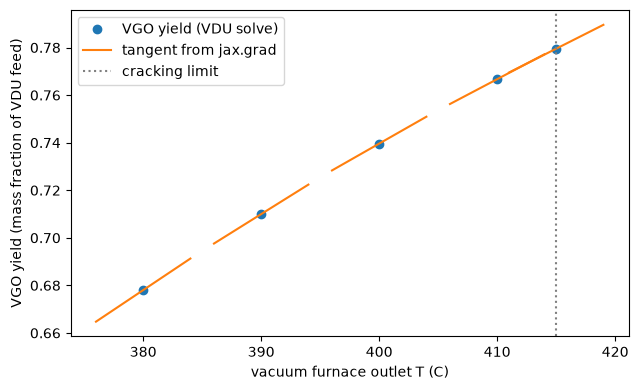

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(T_sweep - C, Y, "o", label="VGO yield (VDU solve)")
for T, y, g in zip(T_sweep, Y, G):
    dT = np.array([-4.0, 4.0])
    ax.plot(T - C + dT, y + g * dT, "-", color="C1", lw=1.5)
ax.plot([], [], "-", color="C1", label="tangent from jax.grad")
ax.axvline(415.0, color="grey", ls=":", label="cracking limit")
ax.set_xlabel("vacuum furnace outlet T (C)"); ax.set_ylabel("VGO yield (mass fraction of VDU feed)")
ax.legend(); plt.tight_layout()

## 6. Into the blend pool

The blend pool reads the same characterization. A product stream from either
column becomes a `BlendComponent`, and its sulfur and gravity are averaged over
the same per-cut vectors. The pool's LVGO sulfur is therefore the same number
the vacuum column reports for its own product.

In [8]:
grid = dr.BlendCharacterization.from_characterization(char)
props = streams["vdu_info"]["properties"]
comps = {n: dr.BlendComponent.from_stream(n, streams[n], grid) for n in ("diesel", "lvgo", "hvgo")}
for n, c in comps.items():
    vdu_S = f"   (VDU reports {1e4 * float(props[n]['sulfur_wt']):.1f})" if n in props else ""
    print(f"{n:>7}: S {float(c.properties['S_ppm']):8.1f} ppm   SG {float(c.properties['SG']):.4f}{vdu_S}")

blend = dr.BlendPool("diesel_pool", specs=[("S_ppm", "<=", 15.0)])(
    [comps["diesel"], comps["lvgo"]], [0.7, 0.3])
print(f"\n70/30 diesel/LVGO: S {float(blend.properties['S_ppm']):.0f} ppm, "
      f"SG {float(blend.properties['SG']):.4f}  (straight-run, before hydrotreating)")

 diesel: S   6828.1 ppm   SG 0.8341
   lvgo: S  19063.9 ppm   SG 0.8917   (VDU reports 19063.9)
   hvgo: S  32655.2 ppm   SG 0.9426   (VDU reports 32655.2)

70/30 diesel/LVGO: S 10673 ppm, SG 0.8514  (straight-run, before hydrotreating)


## Summary

- One assay with a `HeavyEnd` is characterized once. The crude unit, the
  vacuum column and the blend pool all read that one characterization, and
  nothing is re-cut between them.
- In a difflow `Flowsheet` the CDU residue feeds the VDU directly. The
  balance closes per component and in total, with both units' steam counted.
- The VGO yield is differentiable in the vacuum furnace temperature, and the
  gradient comes from the implicit-function theorem through the converged
  column. It agrees with a central difference to about 1e-7. Going from 380 C
  to the 415 C limit raises the VGO yield from 0.68 to 0.78, and the slope
  falls by a quarter over that range as the residue's lighter material runs
  out.
- Sulfur in the pool and sulfur in the vacuum column's report are the same
  number, because both average the same per-cut vector.